# Run and interpret a small PhAST fracture calculation

**Learning objective.** Build an actual PhAST calculation from one configuration, import its prepared T3 mesh, prescribe symmetric tension and initial damage, and interpret reopened displacement, damage and reaction data.

**Predict first.** Predict whether the mesh contains more nodes or elements, and where damage is likely to increase as the imposed displacement grows.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

<div class="badge-row">
<a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/01_phast_tiny_evolving_fracture.ipynb"><img src="../_static/colab-badge.svg" alt="Open in Colab"/></a>
<a class="badge-link" href="../../notebooks/study/01_phast_tiny_evolving_fracture.ipynb">Download Practice Notebook</a>
<a class="badge-link" href="../../notebooks/solutions/01_phast_tiny_evolving_fracture.ipynb">Download with Worked Solutions</a>
<a class="badge-link" href="../../SETUP.md">Environment Setup</a>
</div>

Pulling the top and bottom of a specimen apart stores elastic energy. A phase-field model describes the competition between that stored energy and the energy associated with a diffuse damaged region. We follow this process in a $4\times2$ rectangle containing a short, initially damaged centreline.

The calculation uses the public PhAST AT2 model, isotropic energy degradation, plane-strain kinematics and sparse-direct quasistatic mechanics. Plane strain assumes zero out-of-plane strain. Its fields illustrate diffuse damage evolution under the stated restraints. All quantities use consistent **dimensionless teaching scales**.

The workflow is **configuration → geometry → mesh import → constraints and load → solve → save and reopen → interpretation**. The same objects pass through this complete chain.

In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))


setup_seconds = setup_receipt["setup_seconds"]
computation_started = time.perf_counter()

import copy
import json
import os
from io import BytesIO
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from IPython.display import Image, display
from day2_helpers import assets_dir, import_public_phast, load_forward_config
from day2_helpers.course_tools import _structured_triangles
from day2_helpers.forward_workflow import (solver_configuration, solve_prepared_case,
                                         save_results, load_results, digest_file, notebook_source_hash)

torch.set_default_dtype(torch.float64)
torch.set_num_threads(min(4, os.cpu_count() or 1))
plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
                    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
                    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
                    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
                    "grid.alpha": .3, "grid.linestyle": "--", "lines.linewidth": 1.8})

def show_figure(fig, name, alt):
    fig.savefig(assets_dir() / name, dpi=150, bbox_inches="tight")
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))
    plt.close(fig)

print({"torch": torch.__version__, "device": "cpu", "dtype": "float64", "cloud_setup": IN_COLAB})

{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.018}


{'torch': '2.8.0', 'device': 'cpu', 'dtype': 'float64', 'cloud_setup': False}


## 1. Describe the specimen and predict its response

The width is $W=4$, the height is $H=2$, and the nominal notch length is $a=0.8$. The notch is represented by nodes held at damage $d=1$ along $y=H/2$, from the left edge to $x\leq a$. The surrounding domain starts at $d=0$; its triangular connectivity remains continuous.

The total prescribed separation is $\delta=0.04\lambda$, where the load factor $\lambda$ increases from $0.0125$ to $1$. Symmetric tension prescribes

$$u_y^{\mathrm{top}}=+\frac{\delta}{2},\qquad u_y^{\mathrm{bottom}}=-\frac{\delta}{2}.$$

Horizontal displacement $u_x$ is fixed on all four exterior edges. These lateral restraints form part of this teaching case. Before running it, predict where damage will increase and how halving $\delta$ should affect the stored elastic energy.

{'public_revision': 'f6324f899f0701769810be117f27f1208f7a582e', 'verification': 'COURSE_SOURCE_MANIFEST.json hashes verified', 'geometry': {'width': 4.0, 'height': 2.0, 'notch_length': 0.8, 'description': 'A rectangular specimen with a centreline phase-field Dirichlet precrack from x=0 to x=notch_length.'}, 'mesh': {'nx': 128, 'ny': 64, 'element_type': 'T3', 'dtype': 'float64'}, 'loading': {'total_symmetric_vertical_displacement': 0.04, 'n_load_steps': 60, 'first_load_factor': 0.0125, 'last_load_factor': 1.0}}


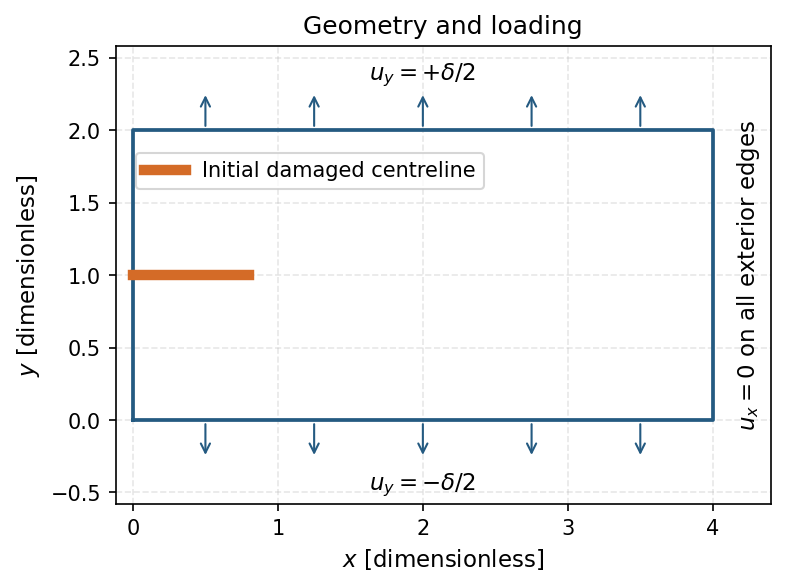

In [2]:
config = load_forward_config()  # Edit this one dictionary to define the case.
phast_info = import_public_phast(config["public_source"]["revision"])
torch.manual_seed(config["seed"])
geometry, mesh_cfg = config["geometry"], config["mesh"]
width, height, notch_length = (geometry[key] for key in ("width", "height", "notch_length"))
print({"public_revision": phast_info["revision"], "verification": phast_info["verification"],
       "geometry": geometry, "mesh": mesh_cfg, "loading": config["loading"]})

fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
ax.plot([0, width, width, 0, 0], [0, 0, height, height, 0], color="#245a81")
ax.plot([0, notch_length], [height/2, height/2], color="#d46b27", lw=5, label="Initial damaged centreline")
for x_arrow in np.linspace(.5, width-.5, 5):
    ax.annotate("", xy=(x_arrow, height+.27), xytext=(x_arrow, height), arrowprops={"arrowstyle": "->", "color": "#245a81"})
    ax.annotate("", xy=(x_arrow, -.27), xytext=(x_arrow, 0), arrowprops={"arrowstyle": "->", "color": "#245a81"})
ax.text(width/2, height+.35, r"$u_y=+\delta/2$", ha="center")
ax.text(width/2, -.48, r"$u_y=-\delta/2$", ha="center")
ax.text(width+.15, height/2, r"$u_x=0$ on all exterior edges", rotation=90, va="center")
ax.set(xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal",
       xlim=(-.12, width+.4), ylim=(-.58, height+.58), title="Geometry and loading")
ax.legend(loc="upper left", bbox_to_anchor=(.015, .79))
show_figure(fig, "tiny_notched_tension_geometry.png", "Rectangle with an initially damaged centreline and outward symmetric vertical loading arrows; horizontal displacement is restrained on every exterior edge.")

## 2. Generate, save and import the mesh

Split each of the $n_x\times n_y$ rectangular cells into two three-node triangles (T3). Coordinates have shape $(N,2)$ and connectivity has shape $(N_e,3)$, with zero-based node indices.

We first save these arrays in a compressed NumPy archive (`.npz`). The **reopened arrays construct the actual `FEMMesh`** used below. This prepared tensor-mesh route makes the relationship between a portable file and the solver's in-memory mesh explicit.

In [3]:
from phast.core.mesh import FEMMesh

nx, ny = mesh_cfg["nx"], mesh_cfg["ny"]
assert ny % 2 == 0  # The grid represents the horizontal centreline exactly.
x = torch.linspace(0, width, nx + 1)
y = torch.linspace(0, height, ny + 1)
xx, yy = torch.meshgrid(x, y, indexing="xy")
generated_nodes = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=1)
generated_elements = _structured_triangles(nx, ny)
prepared_mesh_path = assets_dir() / "tiny_notched_tension_prepared_mesh.npz"
np.savez_compressed(prepared_mesh_path, nodes=generated_nodes.numpy(), elements=generated_elements.numpy())
with np.load(prepared_mesh_path, allow_pickle=False) as mesh_file:
    imported_nodes = torch.from_numpy(mesh_file["nodes"].copy())
    imported_elements = torch.from_numpy(mesh_file["elements"].copy())
torch.testing.assert_close(imported_nodes, generated_nodes, rtol=0, atol=0)
assert torch.equal(imported_elements, generated_elements)
mesh = FEMMesh.from_tensors(imported_nodes, imported_elements, device="cpu", dtype=torch.float64)
mesh.identify_boundaries()
assert mesh.n_nodes == (nx + 1) * (ny + 1) and mesh.n_elems == 2 * nx * ny
assert mesh.elements.min() >= 0 and mesh.elements.max() < mesh.n_nodes
print({"nodes": mesh.n_nodes, "T3_elements": mesh.n_elems, "boundary_sets": sorted(mesh.node_sets)})

[FEMMesh.from_tensors] 8385 nodes, 16384 T3 elements, h_min=1.830583e-02


{'nodes': 8385, 'T3_elements': 16384, 'boundary_sets': ['bottom', 'left', 'right', 'top']}


## 3. Attach the initial notch, boundary conditions and material

PhAST stores a scalar damage value at each node. We impose $d=1$ on the centreline mask and seed those same nodes in the solver's initial state. The full mesh view identifies the prescribed boundaries; the separate damage view shows the state before loading.

The material parameters are Young's modulus $E$, Poisson's ratio $\nu$, fracture energy $G_c$, and regularisation length $\ell$. Here $E=1$, $\nu=0.3$, $G_c=0.0005$, and $\ell=0.15$. The AT2 model balances degraded elastic energy and a smooth fracture-energy density. Its length scale determines the width over which damage varies.

[StaggeredSolver] Assembling solver (quasi_static)...


[FEMOperators] Initializing (isotropic split, AT2)...


[FEMOperators] dt_CFL = 1.577764e-02 (c_p=1.16)


[PhaseFieldDamageSolver] Initializing CG solver (model=AT2, tol=1.0e-08, max_iter=1000, bounds=post_clamp)...


[PhaseFieldDamageSolver] CG device: cpu, dtype: float64


...

[StaggeredSolver] State allocated: 8385 nodes, 16384 elements, device=cpu, dtype=torch.float64


[PhAST route]


  device=cpu; dtype=torch.float64; elements=T3


  mechanics=QuasiStaticSolver; solver_type=quasi_static; time_integrator=central_difference; backend_requested=scipy; backend_resolved=at first solve


  fracture=AT2; energy_split=isotropic; history_update=hard_max; damage_update=classical; bounds=post_clamp; preconditioner=jacobi


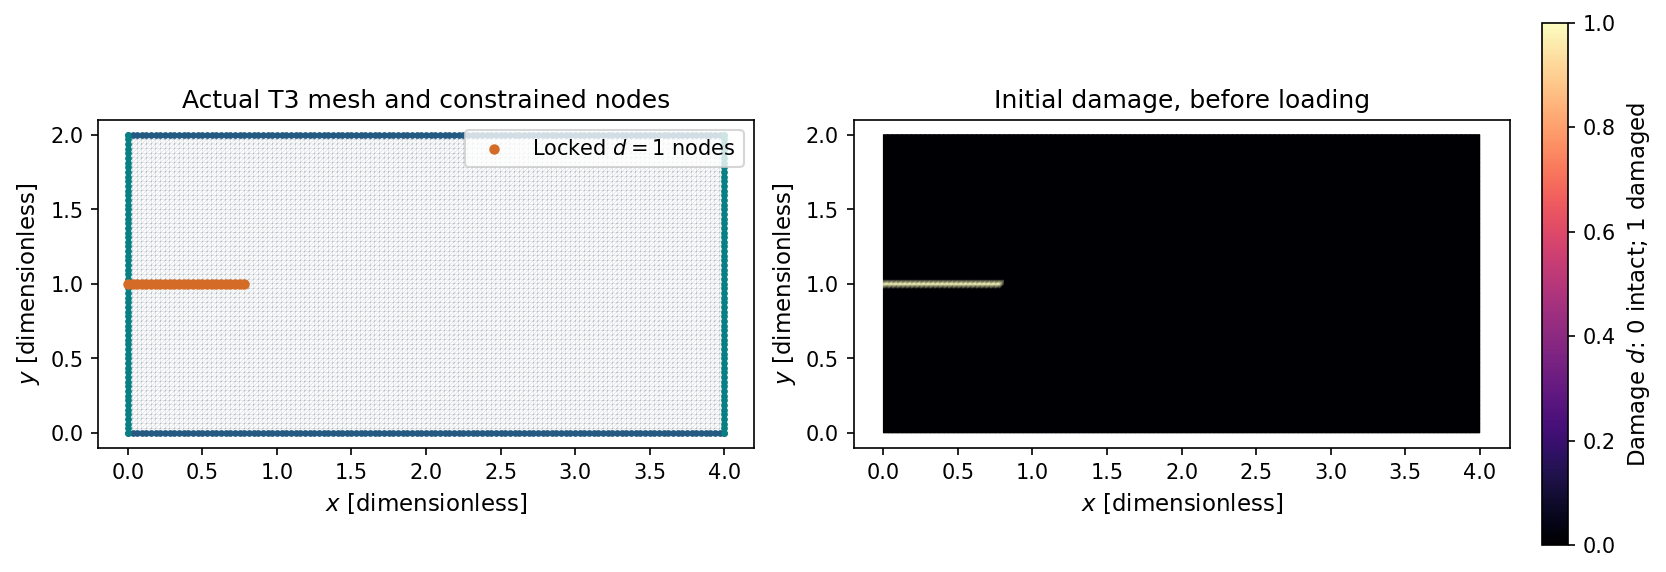

{'locked_precrack_nodes': 26, 'last_locked_x': 0.78125, 'material_kinematics': 'plane strain'}


In [4]:
from phast.physics.boundary_conditions import symmetric_tension_bcs
from phast.physics.material import Material
from phast.solvers.staggered_solver import StaggeredSolver

def construct_solver(case, actual_mesh):
    # Every boundary mask and material value comes from this case and mesh.
    nodes = actual_mesh.nodes
    g = case["geometry"]
    precrack = ((nodes[:, 1] - g["height"]/2).abs() < 1.e-12) & (nodes[:, 0] <= g["notch_length"] + 1.e-12)
    bcs = symmetric_tension_bcs(actual_mesh, disp=case["loading"]["total_symmetric_vertical_displacement"])
    bcs.add_pf_dirichlet(torch.where(precrack)[0], value=1.0)
    material = Material(**case["material"])
    assert material.plane_stress is False  # Retain the reference case's plane-strain kinematics.
    solver = StaggeredSolver(actual_mesh, material, bcs, solver_configuration(case))
    solver.d[precrack] = 1.0
    assert solver.mesh is actual_mesh and solver.bcs is bcs and solver.material is material
    return solver, bcs, material, precrack

solver, bcs, material, precrack = construct_solver(config, mesh)
nodes = mesh.nodes.numpy()
tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], mesh.elements.numpy())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), layout="constrained")
axes[0].triplot(tri, color="#b3bbc3", lw=.16)
for name, color in (("top", "#245a81"), ("bottom", "#245a81"), ("left", "#087f83"), ("right", "#087f83")):
    boundary = mesh.node_sets[name].numpy()
    axes[0].scatter(nodes[boundary, 0], nodes[boundary, 1], s=5, c=color)
axes[0].scatter(nodes[precrack, 0], nodes[precrack, 1], s=16, c="#d46b27", label=r"Locked $d=1$ nodes")
axes[0].legend(loc="upper right")
axes[0].set_title("Actual T3 mesh and constrained nodes")
field = axes[1].tripcolor(tri, solver.d.numpy(), cmap="magma", vmin=0, vmax=1, shading="gouraud")
axes[1].set_title("Initial damage, before loading")
for ax in axes:
    ax.set(xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal")
    ax.grid(False)
fig.colorbar(field, ax=axes[1], label=r"Damage $d$: 0 intact; 1 damaged")
show_figure(fig, "tiny_notched_tension_initial_notch.png", "Actual imported triangular mesh with its constrained exterior nodes and locked centreline nodes; separate full initial damage field with scale zero to one.")
print({"locked_precrack_nodes": int(precrack.sum()), "last_locked_x": float(mesh.nodes[precrack, 0].max()),
       "material_kinematics": "plane stress" if material.plane_stress else "plane strain"})

## 4. Apply the load schedule and solve

At each prescribed separation, the staggered scheme alternates mechanical equilibrium, the damage-driving history, and the phase-field update until its tolerance is met. The load factor indexes a sequence of quasistatic equilibrium problems. The mechanics subproblem uses SciPy's sparse-direct backend.

The helper below advances **the `solver` constructed above**. Within each load step it checks the imposed displacements, damage bounds, irreversibility and convergence of the staggered iterates. The selected criterion is `relative`, with the Euclidean ($L^2$) norm. At staggered iteration $k$, the recorded quantity `stagger_residual` is

$$\eta_k=\max\left(\frac{\|\mathbf u^k-\mathbf u^{k-1}\|_2}{\|\mathbf u^k\|_2+\epsilon},\frac{\|\mathbf d^k-\mathbf d^{k-1}\|_2}{\|\mathbf d^k\|_2+\epsilon}\right),\qquad \epsilon=10^{-30}.$$

The update is accepted when both relative changes fall below $10^{-5}$. This iterate-change measure describes stabilization of the coupled fields; mechanical equilibrium is handled by the mechanics subproblem and its convergence checks. The mechanics and staggered nonconvergence checks stay enabled throughout.

In [5]:
loading = config["loading"]
load_factors = torch.linspace(loading["first_load_factor"], loading["last_load_factor"], loading["n_load_steps"])
print({"increments": len(load_factors), "first_separation": float(load_factors[0] * loading["total_symmetric_vertical_displacement"]),
       "final_separation": float(load_factors[-1] * loading["total_symmetric_vertical_displacement"])})
result = solve_prepared_case(solver, config, load_factors, precrack, phast_info)
assert result["solver"] is solver and solver.mesh is mesh
summary = result["metadata"]["summary"]
assert summary["incremental_damage_outside_sum"] > 1.0
assert summary["incremental_damage_outside_max"] > 1.e-3
assert summary["solve_seconds"] < config["limits"]["solver_seconds_hard"]
print({"solve_seconds": round(summary["solve_seconds"], 2), "load_steps": summary["load_steps"],
       "checks": result["metadata"]["checks"]})

{'increments': 60, 'first_separation': 0.0005, 'final_separation': 0.04}


[QuasiStaticSolver] mechanics backend: scipy (SciPy SuperLU sparse-direct LU); tangent=isotropic linear tangent; free_dofs=16128


{'solve_seconds': 60.09, 'load_steps': 60, 'checks': {'finite_states': True, 'damage_bounds': True, 'irreversibility': True, 'maximum_boundary_error': 0.0, 'minimum_damage_increment': 0.0, 'state_tolerance': 1e-10, 'strict_mechanics_and_stagger_flags': True, 'stagger_residual_checked_each_step': True, 'warning_count': 0}}


## 5. Save and reopen the numerical results

The result archive contains coordinates, triangle connectivity, boundary labels, initial and final damage, the final displacement vector, and selected state snapshots. The JSON companion records the complete configuration, public solver revision, resolved plane-strain state and relative-$L^2$ convergence criterion, conventions, checks and the scalar trace at every load step. `snapshot_steps` identifies each saved state; step zero denotes the initial condition. Reloading checks boundary indices, increasing snapshot IDs and agreement between the named initial/final arrays and the corresponding snapshots.

These are portable **post-processing results**. They can be reopened with NumPy and JSON independently of a live solver object. A restart workflow additionally requires the solver's full internal state.

In [6]:
result["metadata"]["source_hashes"] = {
    name: digest_file(COURSE_ROOT / name) for name in (
        "notebooks/day2_helpers/forward_workflow.py",
        "configs/day2_forward/tiny_notched_tension.json")}
notebook_path = "notebooks/01_phast_tiny_evolving_fracture.ipynb"
result["metadata"]["notebook_source"] = {
    "path": notebook_path,
    "cell_source_sha256": notebook_source_hash(COURSE_ROOT / notebook_path),
    "authored_file_sha256": digest_file(COURSE_ROOT / notebook_path)}
field_path, metadata_path = save_results(result, assets_dir())
saved, record = load_results(field_path, metadata_path)
for name, array in result["arrays"].items():
    np.testing.assert_array_equal(saved[name], array)
assert record["config"] == config
print({"fields_file": field_path.name, "case_file": metadata_path.name,
       "displacement_shape": saved["final_displacement"].shape,
       "kinematics": record["resolved_model"]["kinematics"],
       "stagger_criterion": record["resolved_solver"]["stagger_criterion"],
       "stagger_norm": record["resolved_solver"]["stagger_norm"], "reload": "all arrays match exactly"})

{'fields_file': 'tiny_notched_tension_fields.npz', 'case_file': 'tiny_notched_tension_summary.json', 'displacement_shape': (8385, 2), 'kinematics': 'plane strain', 'stagger_criterion': 'relative', 'stagger_norm': 'l2', 'reload': 'all arrays match exactly'}


## 6. Interpret displacement, damage and reaction

All plots in this section use the reopened files. The displacement view displays the vertical component $u_y$ at the final increment. A deformed outline, magnified by a stated factor, makes the displacement direction visible. Read it alongside the full damage field: increasing damage reduces the local stiffness.

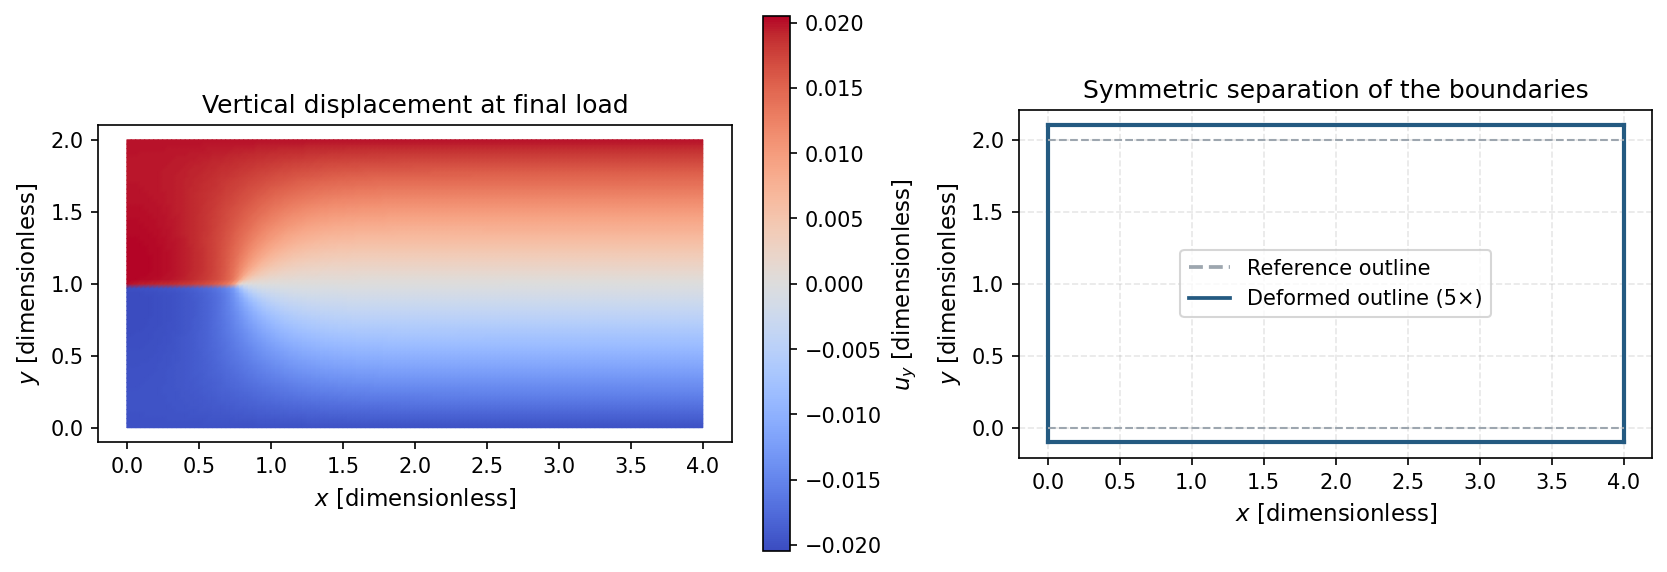

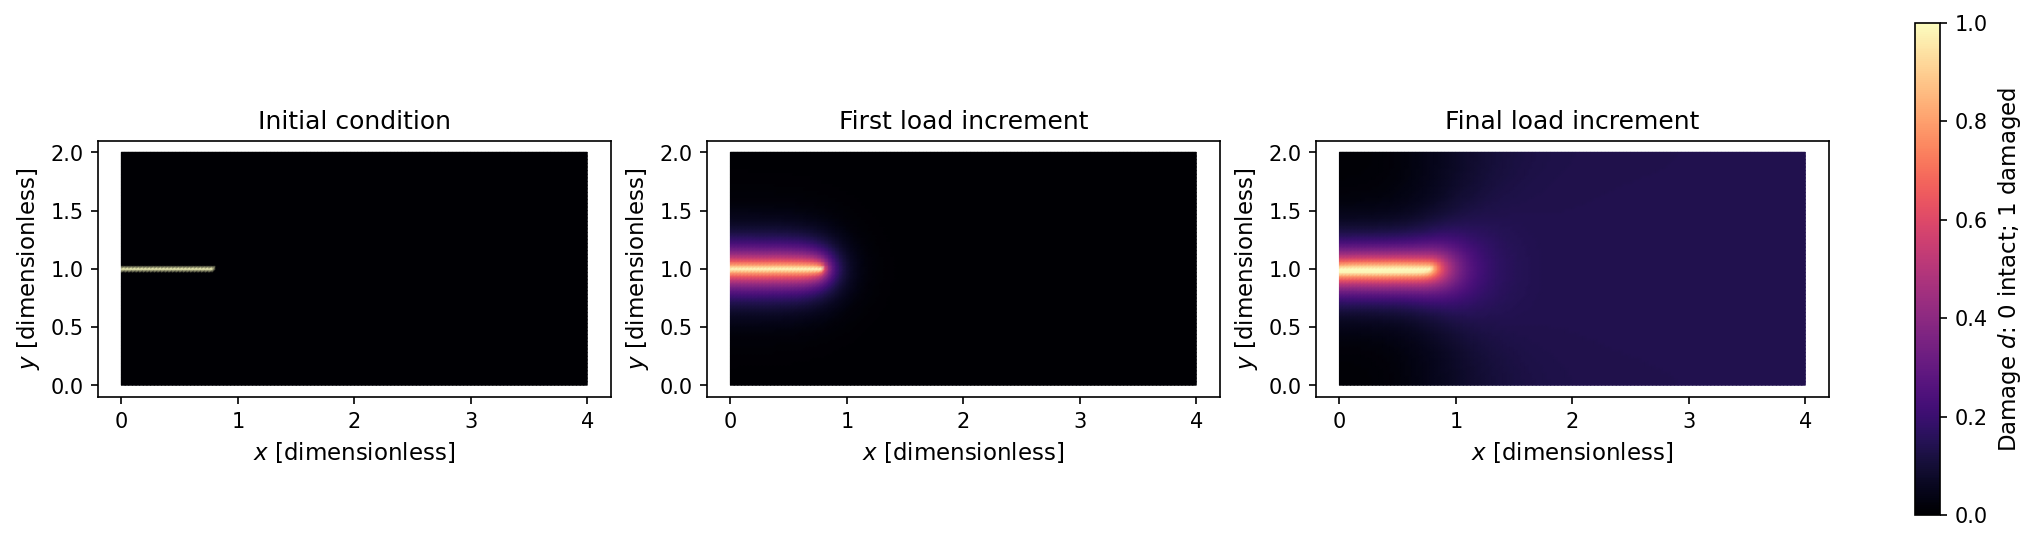

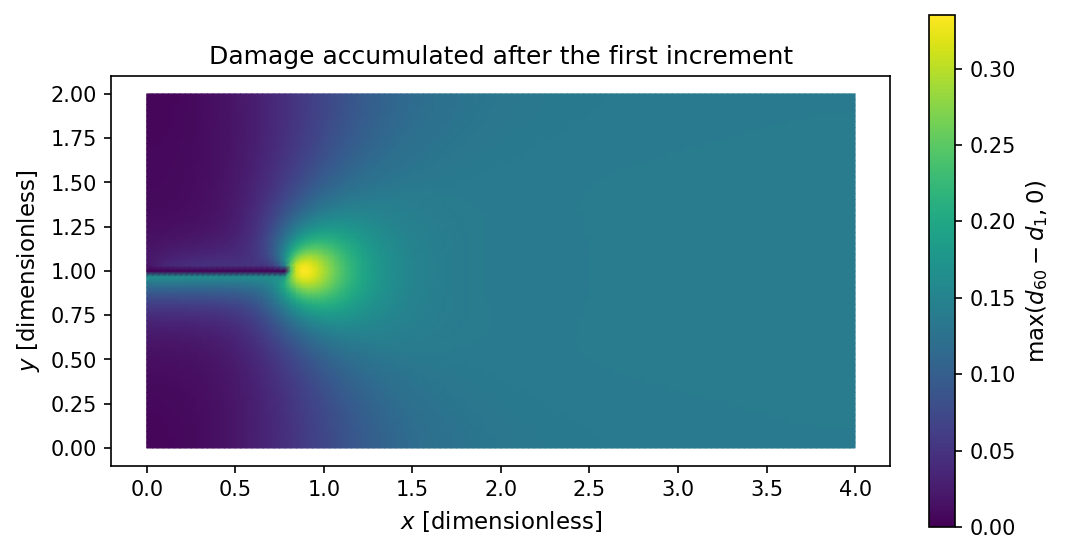

In [7]:
nodes, triangles = saved["nodes"], saved["elements"]
tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)
u = saved["final_displacement"]
deformation_scale = 5
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), layout="constrained")
umax = np.abs(u[:, 1]).max()
image = axes[0].tripcolor(tri, u[:, 1], cmap="coolwarm", vmin=-umax, vmax=umax, shading="gouraud")
fig.colorbar(image, ax=axes[0], label=r"$u_y$ [dimensionless]")
axes[0].set_title("Vertical displacement at final load")
deformed = nodes + deformation_scale * u
for name in ("left", "right", "top", "bottom"):
    idx = saved["boundary_" + name]
    axes[1].plot(nodes[idx, 0], nodes[idx, 1], color="#9da6af", lw=1, linestyle="--")
    axes[1].plot(deformed[idx, 0], deformed[idx, 1], color="#245a81", lw=2)
axes[1].plot([], [], "--", color="#9da6af", label="Reference outline")
axes[1].plot([], [], color="#245a81", label=f"Deformed outline ({deformation_scale}×)")
axes[1].legend(loc="center")
axes[1].set_title("Symmetric separation of the boundaries")
for ax in axes:
    ax.set(xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal")
show_figure(fig, "tiny_notched_tension_displacement.png", "Final vertical displacement with a symmetric color range, alongside the reference and five-times magnified deformed specimen outlines.")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), layout="constrained")
for ax, name, title in zip(axes, ("seeded_damage", "first_damage", "final_damage"),
                         ("Initial condition", "First load increment", "Final load increment")):
    field = ax.tripcolor(tri, saved[name], cmap="magma", vmin=0, vmax=1, shading="gouraud")
    ax.set(title=title, xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal")
    ax.grid(False)
fig.colorbar(field, ax=axes, label=r"Damage $d$: 0 intact; 1 damaged")
show_figure(fig, "tiny_notched_tension_damage.png", "Full initial, first-increment and final PhAST damage fields, all using the same damage scale from zero to one.")

fig, ax = plt.subplots(figsize=(7, 3.6), layout="constrained")
field = ax.tripcolor(tri, saved["incremental_damage"], cmap="viridis", shading="gouraud", vmin=0)
ax.set(title="Damage accumulated after the first increment", xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal")
ax.grid(False)
fig.colorbar(field, ax=ax, label=r"$\max(d_{60}-d_1,0)$")
show_figure(fig, "tiny_notched_tension_increment.png", "Full spatial field of positive damage accrued after the first increment, with a labelled quantitative color scale.")

The top reaction $F_y$ is the sum of the internal vertical forces at the prescribed top nodes. Plotting it against the total separation $\delta$ connects the imposed motion to the mechanical response. The nodal damage sum tracks field evolution on this fixed mesh; its value depends on mesh density. The staggered-iteration plot shows the computational effort at each load level.

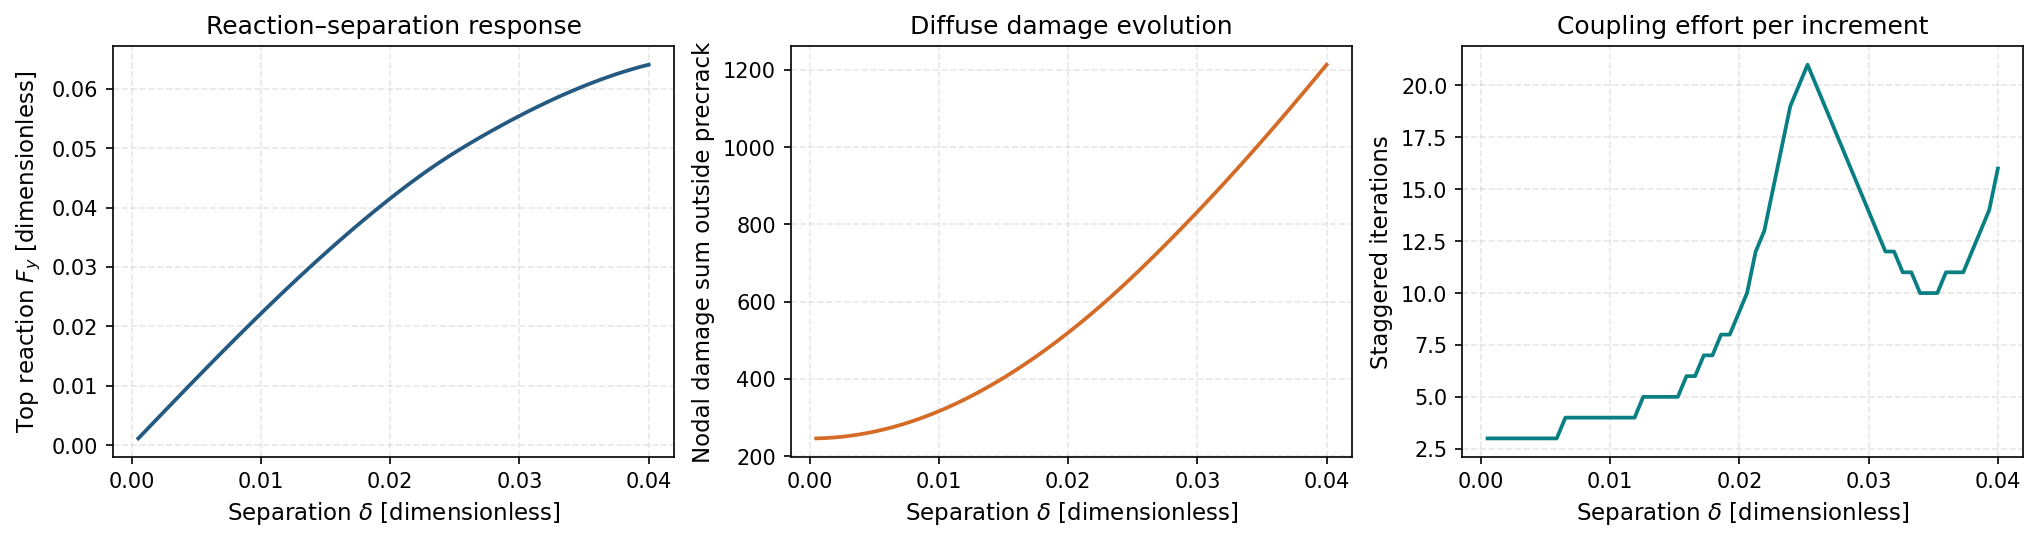

In [8]:
trace = record["trace"]
separation = np.array([row["applied_separation"] for row in trace])
reaction = np.array([row["reaction_top_y"] for row in trace])
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5), layout="constrained")
axes[0].plot(separation, reaction, color="#245a81")
axes[0].set(ylabel=r"Top reaction $F_y$ [dimensionless]", title="Reaction–separation response")
axes[1].plot(separation, [row["damage_outside_sum"] for row in trace], color="#d46b27")
axes[1].set(ylabel="Nodal damage sum outside precrack", title="Diffuse damage evolution")
axes[2].plot(separation, [row["stagger_iterations"] for row in trace], color="#087f83")
axes[2].set(ylabel="Staggered iterations", title="Coupling effort per increment")
for ax in axes:
    ax.set_xlabel(r"Separation $\delta$ [dimensionless]")
show_figure(fig, "tiny_notched_tension_response.png", "Reaction against prescribed separation, nodal damage sum outside the initial notch, and staggered coupling iterations at each increment.")

## 7. Change one input: halve the imposed separation

For a fixed damage field, linear-elastic energy scales with the square of the imposed displacement. Halving the separation therefore reduces that elastic driving energy to one quarter. In the coupled calculation, damage also changes; the new equilibrium response can be assessed from the computed fields.

Copy the configuration and change only the total separation from $0.04$ to $0.02$. Reuse the imported mesh, build a fresh material/constraint/solver state, and execute the same 60 load factors. Predict the relative final damage before running the cell.

[StaggeredSolver] Assembling solver (quasi_static)...


[FEMOperators] Initializing (isotropic split, AT2)...


[FEMOperators] dt_CFL = 1.577764e-02 (c_p=1.16)


[PhaseFieldDamageSolver] Initializing CG solver (model=AT2, tol=1.0e-08, max_iter=1000, bounds=post_clamp)...


[PhaseFieldDamageSolver] CG device: cpu, dtype: float64


...

[PhAST route]


  device=cpu; dtype=torch.float64; elements=T3


  mechanics=QuasiStaticSolver; solver_type=quasi_static; time_integrator=central_difference; backend_requested=scipy; backend_resolved=at first solve


  fracture=AT2; energy_split=isotropic; history_update=hard_max; damage_update=classical; bounds=post_clamp; preconditioner=jacobi


[QuasiStaticSolver] mechanics backend: scipy (SciPy SuperLU sparse-direct LU); tangent=isotropic linear tangent; free_dofs=16128


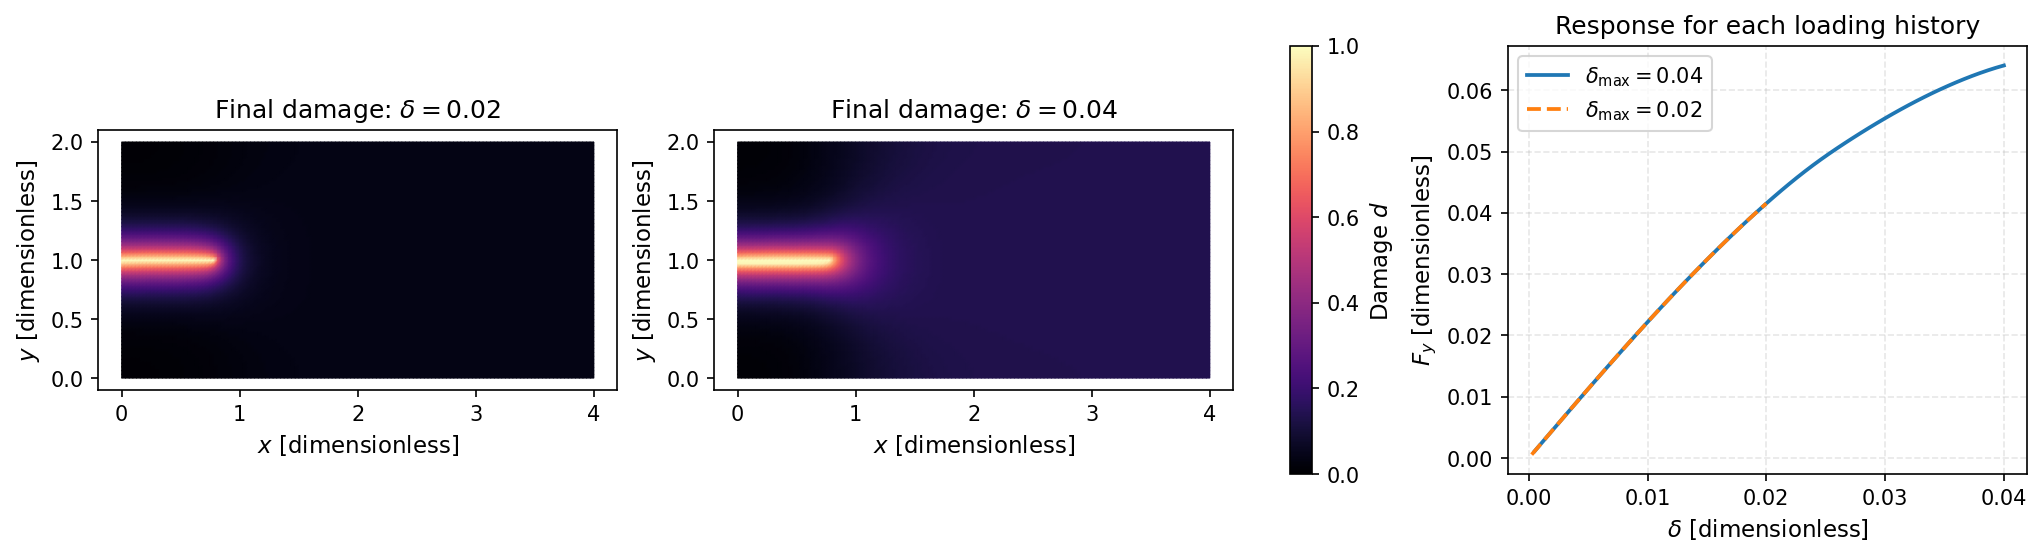

{'full_load_damage_sum': 1213.4936484865932, 'half_load_damage_sum': 519.6831787108099, 'half_load_solve_seconds': 25.29}


In [9]:
smaller_config = copy.deepcopy(config)
smaller_config["loading"]["total_symmetric_vertical_displacement"] *= .5
smaller_solver, smaller_bcs, smaller_material, smaller_precrack = construct_solver(smaller_config, mesh)
smaller_result = solve_prepared_case(smaller_solver, smaller_config, load_factors, smaller_precrack, phast_info)
smaller_fields, smaller_json = save_results(smaller_result, assets_dir(), "tiny_notched_tension_half_load")
smaller_saved, smaller_record = load_results(smaller_fields, smaller_json)
for name, array in smaller_result["arrays"].items():
    np.testing.assert_array_equal(smaller_saved[name], array)
assert np.array_equal(smaller_saved["nodes"], saved["nodes"])
assert np.array_equal(smaller_saved["elements"], saved["elements"])
outside = ~saved["precrack"]
assert smaller_saved["final_damage"][outside].sum() < saved["final_damage"][outside].sum()
assert smaller_record["trace"][-1]["applied_separation"] == .5 * record["trace"][-1]["applied_separation"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), layout="constrained")
for ax, data, title in zip(axes[:2], (smaller_saved, saved), (r"Final damage: $\delta=0.02$", r"Final damage: $\delta=0.04$")):
    field = ax.tripcolor(tri, data["final_damage"], cmap="magma", vmin=0, vmax=1, shading="gouraud")
    ax.set(title=title, xlabel=r"$x$ [dimensionless]", ylabel=r"$y$ [dimensionless]", aspect="equal")
    ax.grid(False)
fig.colorbar(field, ax=axes[:2], label=r"Damage $d$")
for case_record, style, label in ((record, "-", r"$\delta_{\max}=0.04$"), (smaller_record, "--", r"$\delta_{\max}=0.02$")):
    axes[2].plot([r["applied_separation"] for r in case_record["trace"]], [r["reaction_top_y"] for r in case_record["trace"]], style, label=label)
axes[2].set(title="Response for each loading history", xlabel=r"$\delta$ [dimensionless]", ylabel=r"$F_y$ [dimensionless]")
axes[2].legend()
show_figure(fig, "tiny_notched_tension_comparison.png", "Final damage for half and full imposed separation on a shared zero-to-one color scale, with both reaction–separation curves.")
print({"full_load_damage_sum": float(saved["final_damage"][outside].sum()),
       "half_load_damage_sum": float(smaller_saved["final_damage"][outside].sum()),
       "half_load_solve_seconds": round(smaller_record["summary"]["solve_seconds"], 2)})

In [10]:
computation_seconds = time.perf_counter() - computation_started
receipt = {"scope": "all notebook computations after setup, including two full solves, assertions, save/reload and figures",
           "setup_seconds": setup_seconds, "computation_seconds": computation_seconds,
           "installation": "pip installation during cloud setup" if IN_COLAB else "pre-existing local environment",
           "platform": record["environment"], "source_hashes": record["source_hashes"],
           "notebook_source": record["notebook_source"],
           "reference_solve_seconds": record["summary"]["solve_seconds"],
           "half_load_solve_seconds": smaller_record["summary"]["solve_seconds"],
           "reference_checks": record["checks"], "half_load_checks": smaller_record["checks"],
           "reload_equality": True, "one_changed_input": "loading.total_symmetric_vertical_displacement",
           "half_load_has_lower_nodal_damage_sum": True, "colab_execution": IN_COLAB}
(assets_dir() / "tiny_notched_tension_notebook_receipt.json").write_text(json.dumps(receipt, indent=2) + "\n")
assert computation_seconds < config["limits"]["notebook_seconds_hard"]
print({"complete_computation_seconds": round(computation_seconds, 2), "results": "saved and reopened successfully"})

{'complete_computation_seconds': 88.22, 'results': 'saved and reopened successfully'}


## Key takeaways

- The configuration drives geometry, mesh, material, constraints and loading through one connected object chain.
- The initial phase-field notch is a locked nodal damage condition whose endpoint follows the mesh spacing.
- Quasistatic staggered updates couple mechanical equilibrium with diffuse damage evolution; inspect both fields and reactions.
- Portable NPZ/JSON results preserve the numerical arrays and case information needed for independent post-processing.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Count the mesh and the locked precrack

The configuration uses a $4.0\times2.0$ rectangle, $n_x=128$ and $n_y=64$ rectangular cells, and splits each cell into two T3 triangles. The centreline precrack threshold has length $0.8$.

1. Derive the number of nodes and T3 elements.
2. Compute the horizontal node spacing, identify the last grid node satisfying $x\le0.8$, and count the locked centreline nodes.
3. Match your counts to the geometry/mesh cell in the notebook and explain the discretisation effect at the nominal notch endpoint.

::::{admonition} Hint 1
:class: dropdown course-hint

A structured grid with $n_x$ cells has $n_x+1$ nodes in that direction. A T3 split contributes two triangles per rectangle. For the notch, first find $\Delta x=4/128$.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

1. The nodal grid has

$$
N=(128+1)(64+1)=129\times65=8385.
$$

There are $128\times64$ rectangles and two T3 elements per rectangle, so

$$
N_e=2(128)(64)=16384.
$$

2. The horizontal spacing is $\Delta x=4/128=0.03125$. The nominal threshold spans $0.8/0.03125=25.6$ spacings, placing the nominal endpoint $x=0.8$ between grid nodes. The largest admissible integer index is $\lfloor25.6\rfloor=25$, whose coordinate is $25(0.03125)=0.78125$. Nodes with indices $0,\ldots,25$ are locked, giving $25+1=26$ centreline precrack nodes.

3. The setup gives **8385 nodes / 16384 T3 elements** and **precrack_nodes: 26**, so the hand count agrees. This is a discretisation effect: the configuration specifies a threshold at $0.8$, while the nodal Dirichlet mask actually ends at the last represented centreline node within that threshold, $x=0.78125$. The prepared tensor-mesh file stores these generated coordinates, connectivity and node labels.
::::

### Exercise 2: Predict and test the effect of a smaller separation

The final notebook experiment changes only the total imposed separation from $0.04$ to $0.02$.

1. With damage held fixed, derive the factor by which strain and elastic energy change when the prescribed displacement is halved.
2. Use the saved files for the two calculations to compare their final damage fields on the same colour scale and their reaction–separation curves. Explain how the coupled damage update affects the response.
3. Identify the arrays and metadata another student needs to recreate these plots.

::::{admonition} Hint 2
:class: dropdown course-hint

For fixed stiffness, displacement and strain scale linearly with the prescribed separation. Elastic energy is quadratic in strain. The coupled calculation updates damage as the loading progresses.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

1. Let $\boldsymbol\varepsilon$ be the small-strain tensor and $\mathbb C$ the elastic stiffness. Holding damage fixed gives $\boldsymbol\varepsilon_{1/2}=\boldsymbol\varepsilon/2$, so $\psi_{1/2}=\tfrac12(\boldsymbol\varepsilon/2):\mathbb C:(\boldsymbol\varepsilon/2)=\psi/4$.

2. The notebook executes both complete loading histories using the same imported mesh and material. It verifies that the smaller-separation calculation has a smaller final nodal damage sum outside the locked precrack. Compare the full fields using $0\le d\le1$ for both plots. As damage changes the stiffness, the coupled reaction curves reflect both the imposed displacement and damage evolution. A reaction ratio of exactly one half applies to a fixed-damage linear-elastic comparison.

3. The NPZ files supply coordinates, triangle connectivity, boundary node labels and final displacement/damage arrays. The JSON files supply the configuration, dimensionless conventions, public source revision and the per-step `applied_separation` and `reaction_top_y` values. The saved hashes and reload checks establish file integrity and array equality. These result files support portable post-processing; a simulation restart also requires internal history and solver state.
::::